In [189]:
# This notebook intends to grab multiple metrics
# and compare against the validation, additinally
# performance curves comparing all metrics will be
# generated. 

In [190]:

import yaml
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio as rio
from rasterio.crs import CRS
import datetime
from shapely.geometry import box, shape
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from rasterio.plot import show
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, f1_score, accuracy_score
from matplotlib.colors import ListedColormap, BoundaryNorm
import contextily as cx

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",  # Use a serif font
#     "font.serif": ["Times New Roman"],  # Specify the serif font
# })

In [191]:
EVENT_NAME = 'park_fire_2024' 
TRACK_IDX = 0
METRIC_IDX = 6 # options [0, 1, 2, 3, 4, 5, 6] for [CUSUM_PROB_MAX, CUSUM_VH, LOG_RATIO, MAHALANOBIS_1D_MAX, MAHALANOBIS_2D, MAHALANOBIS_VH, TRANSFORMER] respectively
METRIC_IDX_LIST = [6, 0, 2]

In [192]:
# Option to export all plots as png into OUTDIR
plot_export = True

In [193]:
# list of available metrics 
all_metric_names_lst = [
    "cusum_prob_max",
    "cusum_vh",
    "log_ratio_vh",
    "mahalanobis_1d_max",
    "mahalanobis_2d",
    "mahalanobis_vh",
    "transformer"
    ]

current_metric = all_metric_names_lst[METRIC_IDX]
current_metric

'transformer'

In [194]:
dist_events_dir = Path('/u/aurora-r0/cmarshak/dist-s1-events')
dist_metrics_dir = Path('/u/aurora-r0/cmarshak/dist-s1-calibration/out_metrics')
print(dist_events_dir, dist_metrics_dir)

/u/aurora-r0/cmarshak/dist-s1-events /u/aurora-r0/cmarshak/dist-s1-calibration/out_metrics


In [195]:
# Read event info
yaml_file = dist_events_dir / f'events/{EVENT_NAME}.yml'
with open(yaml_file) as f:
    event_dict = yaml.safe_load(f)["event"]
event_dict

{'event_name': 'park_fire_2024',
 'bounds': [-122.063588, 39.770975, -121.49483901, 40.394684],
 'event_date': '2024-07-24',
 'pre_event_window_days': 180,
 'post_event_window_days': 100,
 'rtc_track_numbers': [137, 115],
 'mgrs_tiles': ['10TEK', '10TFK'],
 'dist_hls_confirmed_change_min_days': 15,
 'source_id': 'WFIGS Park Fire 2024',
 'links': ['https://en.wikipedia.org/wiki/Park_Fire']}

In [196]:
# Get date and tracks
EVENT_DATE = event_dict['event_date']
TRACKS = event_dict['rtc_track_numbers']
print('Event date:', EVENT_DATE)
print('Tracks:', TRACKS)
print('Using track:', TRACKS[TRACK_IDX])

Event date: 2024-07-24
Tracks: [137, 115]
Using track: 137


In [197]:
# Event data
EVENT_DATA = dist_events_dir / 'out' / EVENT_NAME
# Get preprocessed datasets for specified event
RTC_DIR = EVENT_DATA / 'rtc_ts_merged'
DIST_HLS_CM_DIR = EVENT_DATA / 'change_map_dist_hls'
WATER_MASK_DIR = EVENT_DATA / 'water_mask'
VAL_DATA_DIR = EVENT_DATA / 'validation_data'
all([d.exists() for d in [RTC_DIR, DIST_HLS_CM_DIR, WATER_MASK_DIR, VAL_DATA_DIR]])

True

In [198]:
# Get paths to metrics
track_number = f'track{TRACKS[TRACK_IDX]}'
EVENT_METRICS = dist_metrics_dir / EVENT_NAME / track_number 

CUSUM_PROB_MAX = EVENT_METRICS /'cusum_prob_max'
CUSUM_VH = EVENT_METRICS / 'cusum_vh'
LOG_RATIO = EVENT_METRICS / 'log_ratio_vh'
MAHALANOBIS_1D_MAX = EVENT_METRICS / 'mahalanobis_1d_max'
MAHALANOBIS_2D = EVENT_METRICS / 'mahalanobis_2d'
MAHALANOBIS_VH = EVENT_METRICS / 'mahalanobis_vh'
TRANSFORMER = EVENT_METRICS / 'transformer'

METRIC_LIST = [CUSUM_PROB_MAX, CUSUM_VH, LOG_RATIO, MAHALANOBIS_1D_MAX, 
               MAHALANOBIS_2D, MAHALANOBIS_VH, TRANSFORMER]

all([d.exists() for d in METRIC_LIST])

True

In [199]:
# Set up out directory for the metric summary outputs
TEMPDIR = Path('/u/aurora-r0/cabrera/opera_dist/testing') # this is a temporary dir used during testing
OUT_DIR = TEMPDIR / 'atbd_figs' / EVENT_NAME 
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR, OUT_DIR.exists()

(PosixPath('/u/aurora-r0/cabrera/opera_dist/testing/atbd_figs/park_fire_2024'),
 True)

### Visualize metrics

##### Gather metric paths and names from list of interest (METRIC_IDX_LIST)

In [200]:
## Select metric map index 
# # select which post metric to load 
# metric_idx = 1 
# Select the list of metrics to read
METRIC_IDX_LIST = [6, 0, 2] #[0, 1, 2, 3, 4, 5, 6] for [CUSUM_PROB_MAX, CUSUM_VH, LOG_RATIO, MAHALANOBIS_1D_MAX, MAHALANOBIS_2D, MAHALANOBIS_VH, TRANSFORMER] respectively

In [201]:
# Initialize dictionaries to store paths and names for each metric index
pre_metric_paths_dict = {}
pre_metric_names_dict = {}
post_metric_paths_dict = {}
post_metric_names_dict = {}

# Loop over the list of METRIC_IDX
for idx in METRIC_IDX_LIST:
    # Get the sorted list of file paths for pre and post metrics for the current index
    pre_metric_paths = sorted(list(METRIC_LIST[idx].glob('pre*.tif')))
    post_metric_paths = sorted(list(METRIC_LIST[idx].glob('post*.tif')))
    
    # Extract the file names (stems) without extensions
    pre_metric_names = [file.stem for file in pre_metric_paths]
    post_metric_names = [file.stem for file in post_metric_paths]
    
    # Store the paths and names in the dictionaries, using idx as the key
    pre_metric_paths_dict[idx] = pre_metric_paths
    pre_metric_names_dict[idx] = pre_metric_names
    post_metric_paths_dict[idx] = post_metric_paths
    post_metric_names_dict[idx] = post_metric_names
    
    # Print the results for the current metric index
    print(f'For METRIC_IDX {idx} = {all_metric_names_lst[idx]}:')
    print('Total pre-metrics:', len(pre_metric_paths))
    print('Total post-metrics:', len(post_metric_paths))
    print('Post metric paths:', post_metric_paths)
    print('')

For METRIC_IDX 6 = transformer:
Total pre-metrics: 2
Total post-metrics: 2
Post metric paths: [PosixPath('/u/aurora-r0/cmarshak/dist-s1-calibration/out_metrics/park_fire_2024/track137/transformer/post_2024-07-29_transformer_track137_park-fire-2024.tif'), PosixPath('/u/aurora-r0/cmarshak/dist-s1-calibration/out_metrics/park_fire_2024/track137/transformer/post_2024-08-10_transformer_track137_park-fire-2024.tif')]

For METRIC_IDX 0 = cusum_prob_max:
Total pre-metrics: 2
Total post-metrics: 2
Post metric paths: [PosixPath('/u/aurora-r0/cmarshak/dist-s1-calibration/out_metrics/park_fire_2024/track137/cusum_prob_max/post_2024-07-29_cusum_prob_max_track137_park-fire-2024.tif'), PosixPath('/u/aurora-r0/cmarshak/dist-s1-calibration/out_metrics/park_fire_2024/track137/cusum_prob_max/post_2024-08-10_cusum_prob_max_track137_park-fire-2024.tif')]

For METRIC_IDX 2 = log_ratio_vh:
Total pre-metrics: 2
Total post-metrics: 2
Post metric paths: [PosixPath('/u/aurora-r0/cmarshak/dist-s1-calibration/out_

In [202]:
# Load list of arrays 
# Initialize dictionaries to store lists of arrays for each metric index
pre_metric_list_dict = {}
post_metric_list_dict = {}

# Loop over the list of METRIC_IDX
for idx in METRIC_IDX_LIST:
    # Initialize lists to store arrays for the current index
    pre_metric_list = []
    post_metric_list = []
    
    # Access pre and post metric paths from the previous dictionaries
    pre_metric_paths = pre_metric_paths_dict[idx]
    post_metric_paths = post_metric_paths_dict[idx]
    
    # Load pre-metric arrays
    for file in pre_metric_paths:
        with rio.open(file) as src:
            array = src.read(1)  # Read the first band of the file
            pre_metric_list.append(array)
    
    # Load post-metric arrays
    for file in post_metric_paths:
        with rio.open(file) as src:
            array = src.read(1)  # Read the first band of the file
            post_metric_list.append(array)
    
    # Store the lists of arrays in the dictionaries, using idx as the key
    pre_metric_list_dict[idx] = pre_metric_list
    post_metric_list_dict[idx] = post_metric_list
    
    # Print results for the current metric index
    print(f"For METRIC_IDX = {idx}:")
    print(f"Loaded {len(pre_metric_list)} pre-metric arrays and {len(post_metric_list)} post-metric arrays.")
    
    # Optional: Print the shape of the first array as an example
    if pre_metric_list:
        print("Shape of first pre-metric array:", pre_metric_list[0].shape)
    if post_metric_list:
        print("Shape of first post-metric array:", post_metric_list[0].shape)
    print("")


For METRIC_IDX = 6:
Loaded 2 pre-metric arrays and 2 post-metric arrays.
Shape of first pre-metric array: (3660, 6994)
Shape of first post-metric array: (3660, 6994)

For METRIC_IDX = 0:
Loaded 2 pre-metric arrays and 2 post-metric arrays.
Shape of first pre-metric array: (3660, 6994)
Shape of first post-metric array: (3660, 6994)

For METRIC_IDX = 2:
Loaded 2 pre-metric arrays and 2 post-metric arrays.
Shape of first pre-metric array: (3660, 6994)
Shape of first post-metric array: (3660, 6994)



In [203]:
# Plotting funct for quick view
def plot_metric(metric_index, pre_metric_arr_dict, pre_metric_names_str_dict, post_metric_arr_dict, post_metric_names_str_dict, slice=np.s_[:,:]):
    # Combine pre- and post-metric arrays and names for the chosen METRIC_IDX
    metrics = pre_metric_arr_dict[metric_index] + post_metric_arr_dict[metric_index]  # Combine pre- and post-metric arrays
    metric_names = pre_metric_names_str_dict[metric_index] + post_metric_names_str_dict[metric_index]  # Combine pre- and post-metric names

    # Set colorbar limits based on the chosen METRIC_IDX
    if metric_index == 0 or metric_index == 1:
        vmin = 0
        vmax = 1
    else:
        vmin = 0
        vmax = 4

    # Number of metrics to plot
    N = len(metrics)

    # Create subplots
    fig, axs = plt.subplots(1, N, figsize=(10 + N * 5, 10), dpi=150, sharey=True)

    # Ensure axs is a list even if there is only one subplot
    if N == 1:
        axs = [axs]

    # Loop over each metric and plot it
    for ax, met, mn in zip(axs, metrics, metric_names):
        # Plot the metric
        im = ax.imshow(met[slice], vmin=vmin, vmax=vmax, interpolation='none')  
        ax.set_title(mn)  # Set the title as the metric name

    # Add a colorbar
    fig.colorbar(im, ax=axs.ravel().tolist())

    # Show the plot
    plt.show()


In [204]:
# Define a subset window
# s = np.s_[1500:3000, 1500:3000] # Chile fire 
# # s = np.s_[700:3300, 2000:5000] # Park fire subset
# s = np.s_[1500:3500, 1000:3000] # Attica fire
# s = np.s_[2000:3500, 500:2000] # Chiapas
# s = np.s_[250:2000, 1750:3500] # papau new guinnea 
# s = np.s_[3150:3200, 2000:2150] # papau new guinnea
# s = np.s_[250:3500, 1000:5000] # demak flood
# s = np.s_[0:2000, 1000:5000] # south west france 
s = np.s_[:,:]

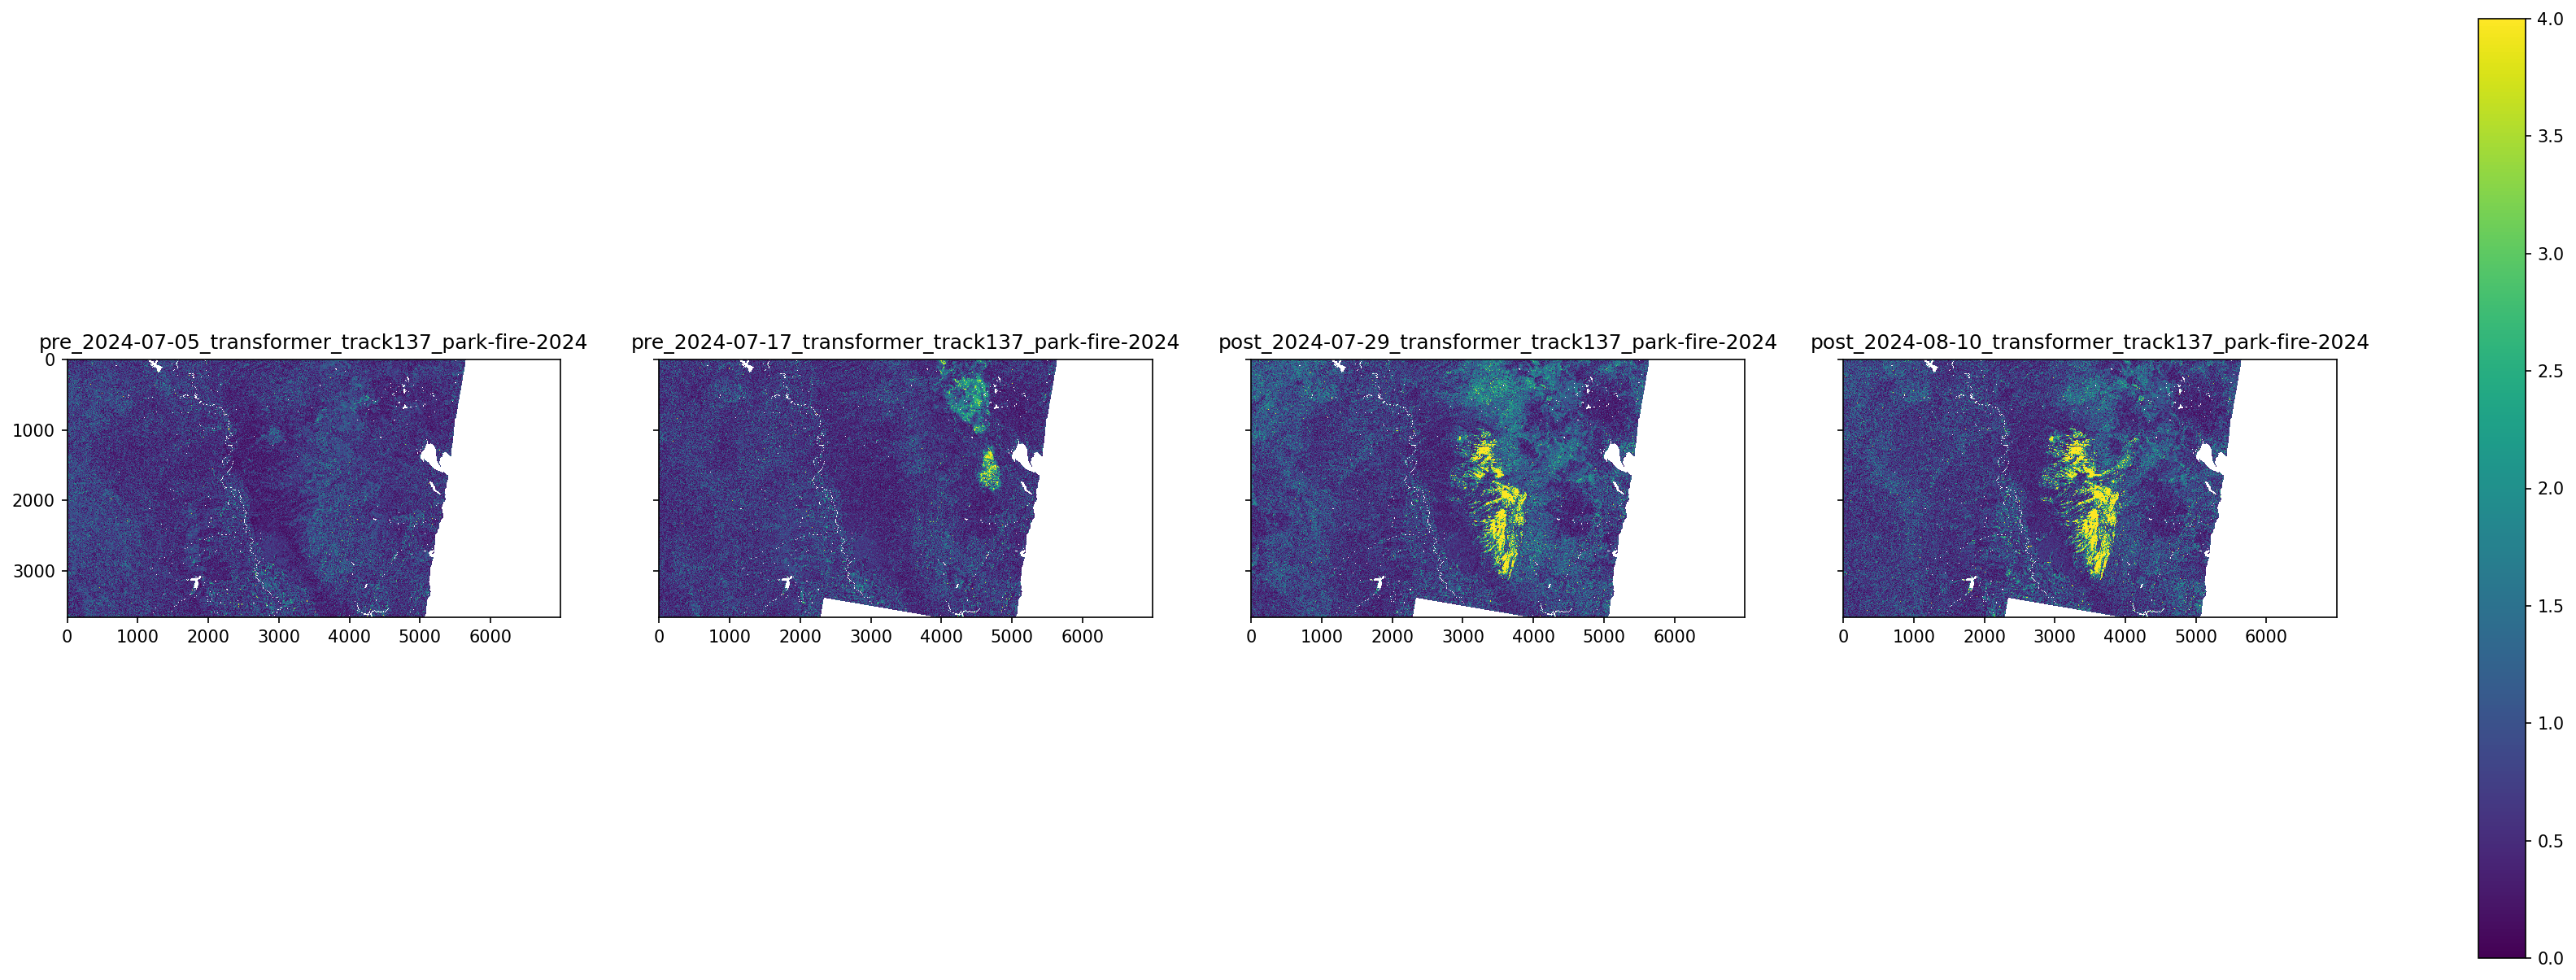

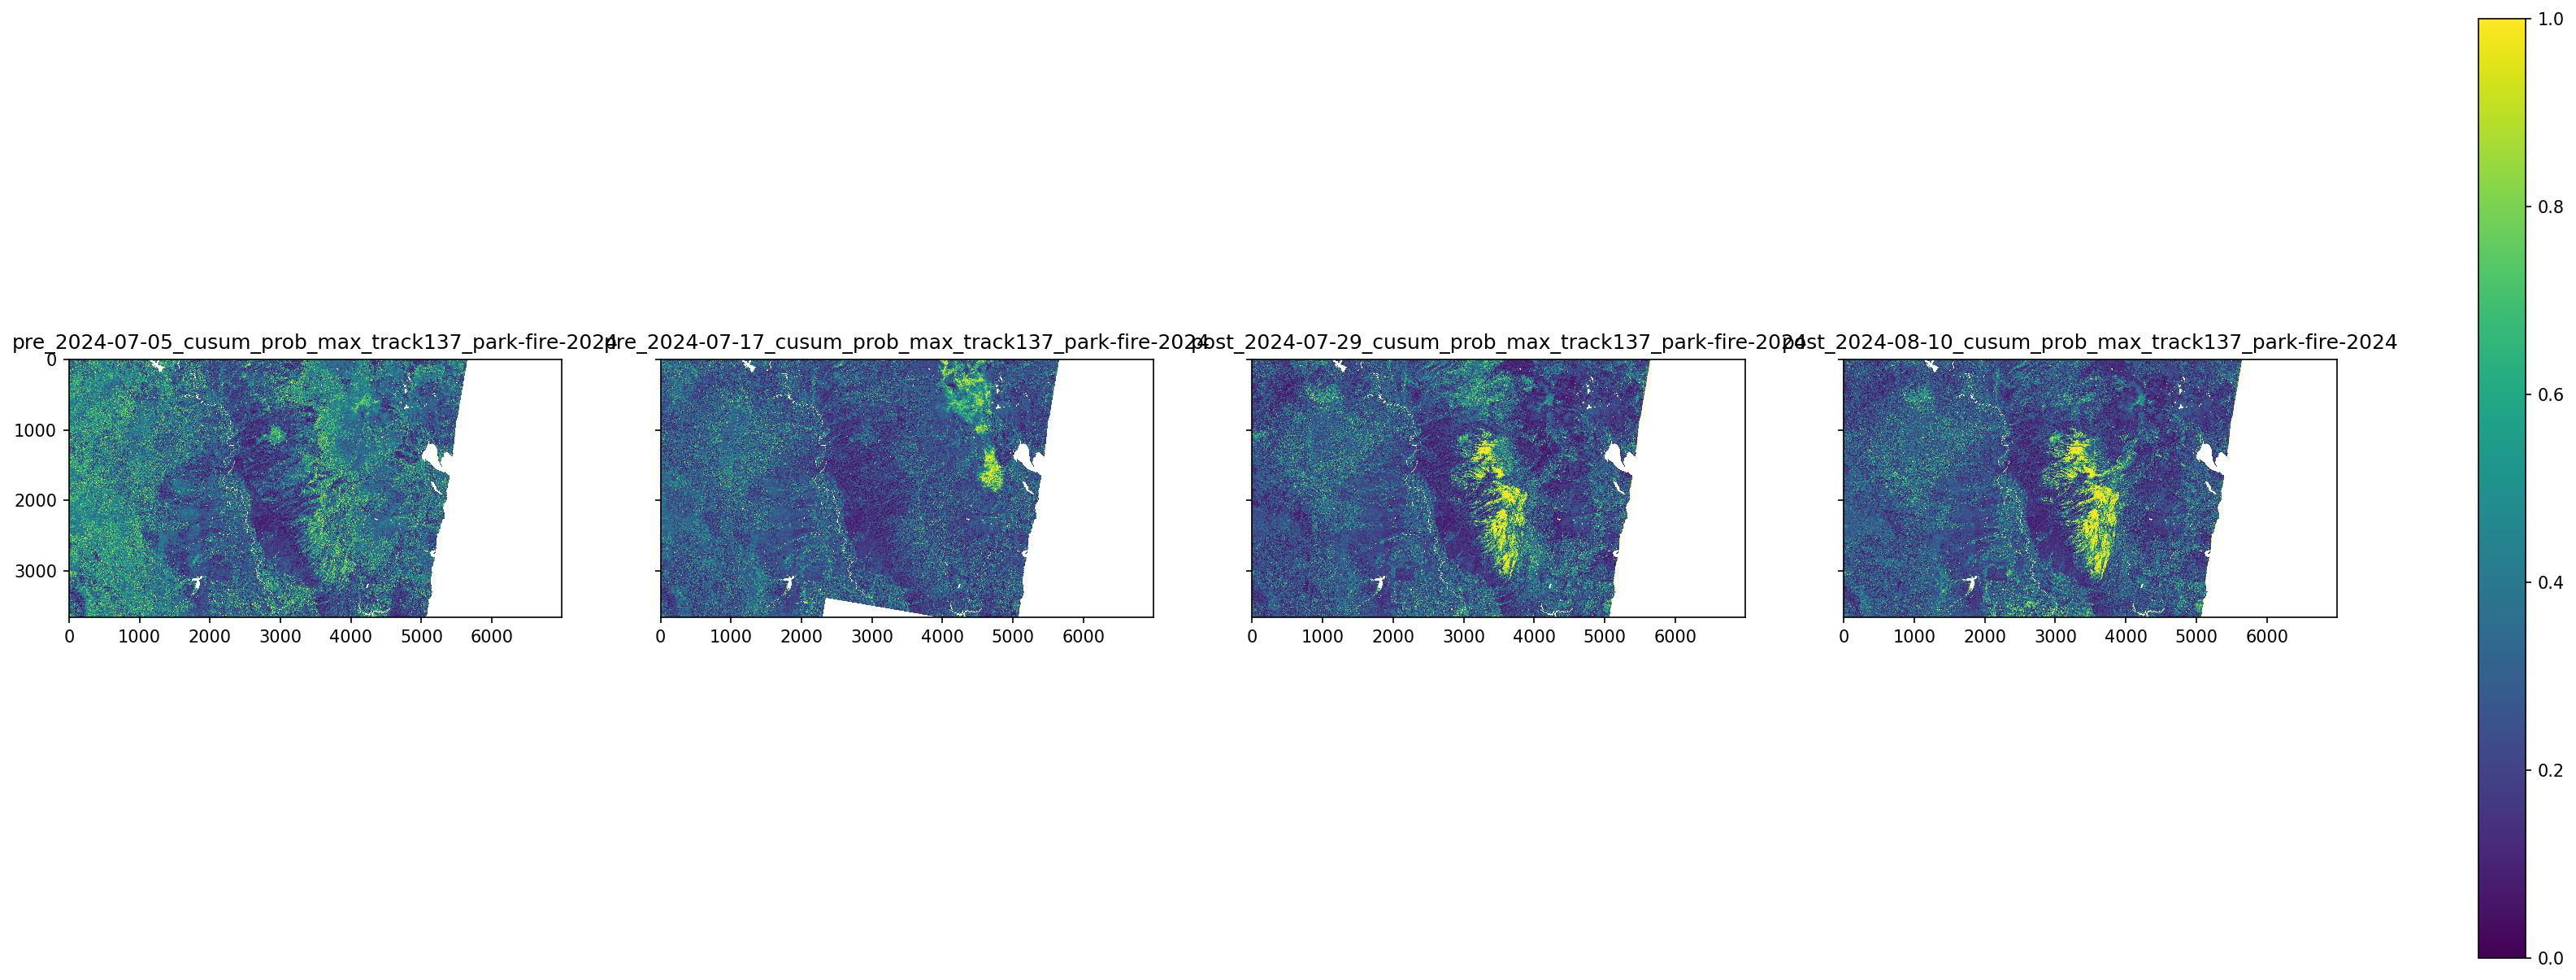

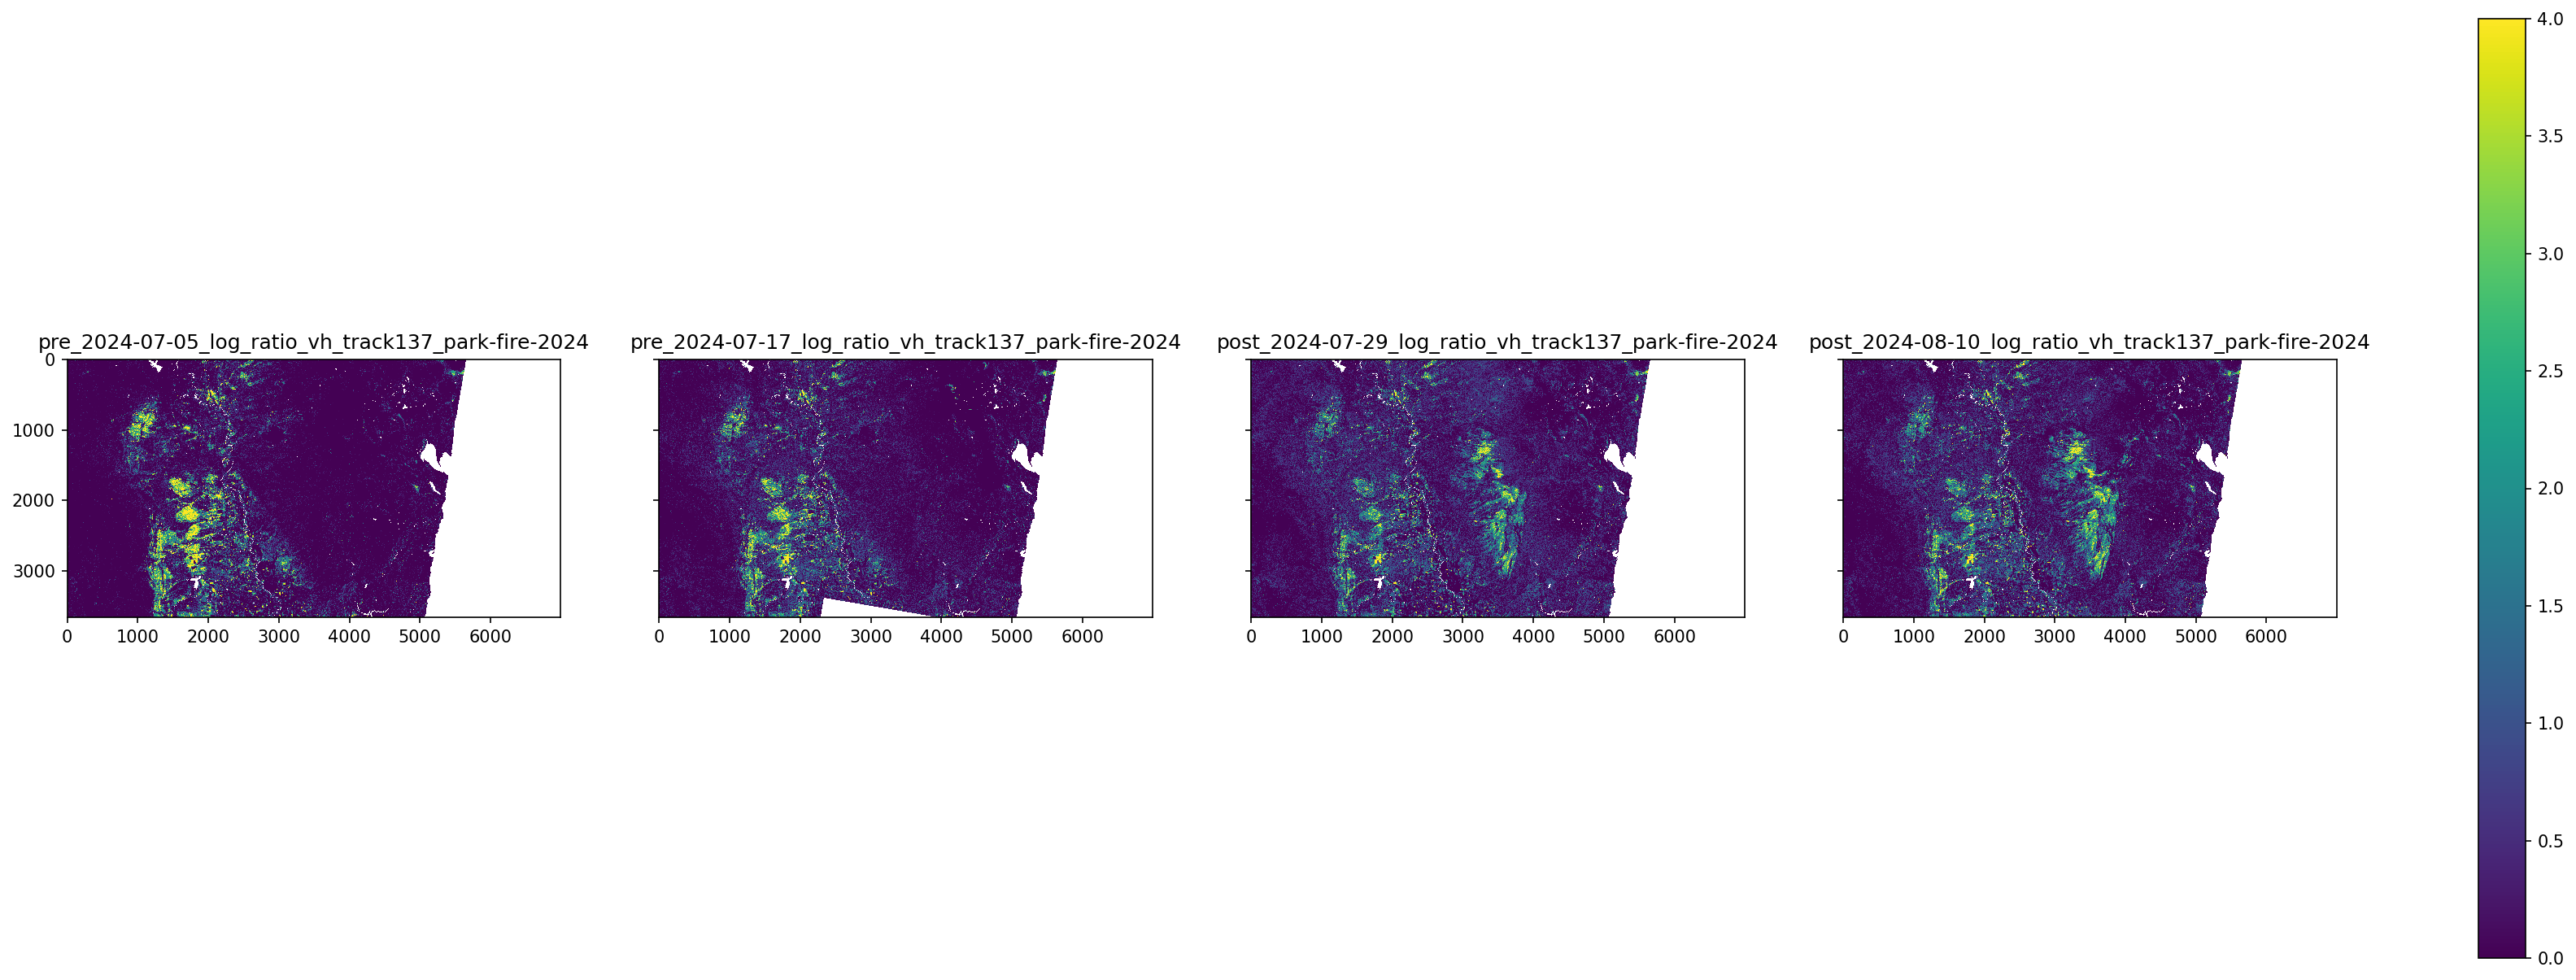

In [205]:
# Specify the METRIC_IDX you want to plot (e.g., METRIC_IDX = 0)
for idx in METRIC_IDX_LIST:
    plot_metric(idx, pre_metric_list_dict, pre_metric_names_dict, post_metric_list_dict, post_metric_names_dict, slice=s)

### After inspecting the metrics choose a pre and post for curve generation

In [206]:
# Attica fire 
if EVENT_NAME == 'attica_fire_2024': 
    event_text_name = 'Attica Fire 2024'
    selected_pre_idx = 1
    selected_post_idx = 1
    s = np.s_[1500:3500, 1000:3000] # Attica fire
    print('---> Selected event:', event_text_name)
    print('->Selected pre metric date:', pre_metric_names_dict[METRIC_IDX][selected_pre_idx])
    print('--> Selected post metric date:', post_metric_names_dict[METRIC_IDX][selected_post_idx])

if EVENT_NAME == 'chile_fire_2024': 
    event_text_name = 'Chile Fire 2024'
    selected_pre_idx = 0
    selected_post_idx = 1
    s = np.s_[1500:3000, 1500:3000] # Chile fire
    print('---> Selected event:', event_text_name)
    print('->Selected pre metric date:', pre_metric_names_dict[METRIC_IDX][selected_pre_idx])
    print('--> Selected post metric date:', post_metric_names_dict[METRIC_IDX][selected_post_idx])

if EVENT_NAME == 'demak_flood_2024': 
    event_text_name = 'Demak Flood 2024'
    selected_pre_idx = 1
    selected_post_idx = 0
    s = np.s_[250:3500, 1000:5000] # demak flood
    print('---> Selected event:', event_text_name)
    print('->Selected pre metric date:', pre_metric_names_dict[METRIC_IDX][selected_pre_idx])
    print('--> Selected post metric date:', post_metric_names_dict[METRIC_IDX][selected_post_idx])

if EVENT_NAME == 'park_fire_2024': 
    event_text_name = 'Park Fire 2024'
    selected_pre_idx = 0
    selected_post_idx = 1
    s = np.s_[700:3300, 2000:5000] # Park fire subset
    print('---> Selected event:', event_text_name)
    print('->Selected pre metric date:', pre_metric_names_dict[METRIC_IDX][selected_pre_idx])
    print('--> Selected post metric date:', post_metric_names_dict[METRIC_IDX][selected_post_idx])

if EVENT_NAME == 'papau_new_guinea_landslide_2024': 
    event_text_name = 'Papua New Guinea Landslide 2024'
    selected_pre_idx = 1
    selected_post_idx = 0
    s = np.s_[3150:3200, 2000:2150] # papau new guinnea
    print('---> Selected event:', event_text_name)
    print('->Selected pre metric date:', pre_metric_names_dict[METRIC_IDX][selected_pre_idx])
    print('--> Selected post metric date:', post_metric_names_dict[METRIC_IDX][selected_post_idx])

if EVENT_NAME == 'southwest_france_flood_2023': 
    event_text_name = 'Southwest France Flood 2023'
    selected_pre_idx = 0
    selected_post_idx = 0
    s = np.s_[0:2000, 1000:5000] # south west france 
    print('---> Selected event:', event_text_name)
    print('->Selected pre metric date:', pre_metric_names_dict[METRIC_IDX][selected_pre_idx])
    print('--> Selected post metric date:', post_metric_names_dict[METRIC_IDX][selected_post_idx])

---> Selected event: Park Fire 2024
->Selected pre metric date: pre_2024-07-05_transformer_track137_park-fire-2024
--> Selected post metric date: post_2024-08-10_transformer_track137_park-fire-2024


### Load and visualize validation data

In [207]:
# Read validation data
val_data_paths = list(VAL_DATA_DIR.glob('*.tif'))
aoi_path = [p for p in val_data_paths if 'extent_datamask' in p.stem][0]
val_path = [p for p in val_data_paths if 'extent' not in p.stem][0]

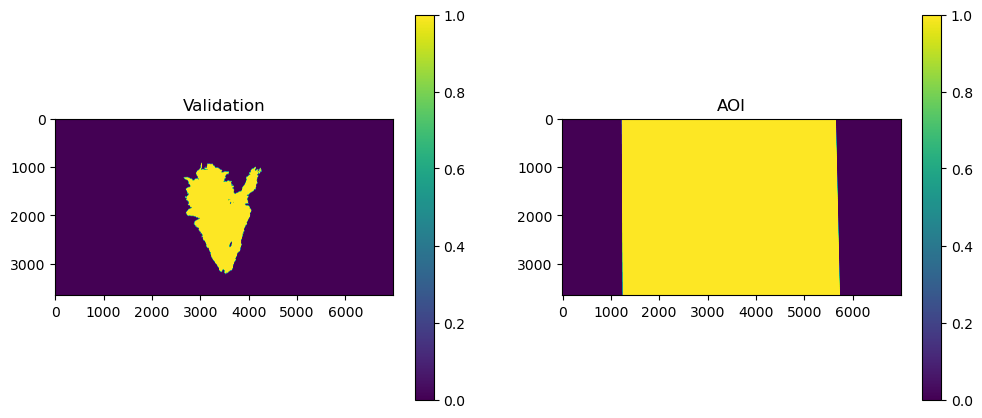

In [208]:
# Visualize validation
with rio.open(val_path) as ds:
    X_val = ds.read(1)
    p_val = ds.profile

with rio.open(aoi_path) as ds:
    X_aoi = ds.read(1)

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
cax = ax.imshow(X_val)
ax.set_title("Validation")
cbar = fig.colorbar(cax, orientation='vertical')
ax = fig.add_subplot(1, 2, 2)
cax = ax.imshow(X_aoi)
ax.set_title("AOI")
cbar = fig.colorbar(cax, orientation='vertical')

if plot_export:
    out_file = OUT_DIR / f'{current_metric}_validation_data.png'
    plt.savefig(out_file, bbox_inches='tight', transparent=True, dpi=150)
plt.show()

In [209]:
# get pre metric and post metric to compare
# METRIC_IDX = 6
# For now use metric pre 0 and post 1
pre_metric = pre_metric_list_dict[METRIC_IDX][selected_pre_idx] 
post_metric = post_metric_list_dict[METRIC_IDX][selected_post_idx] 



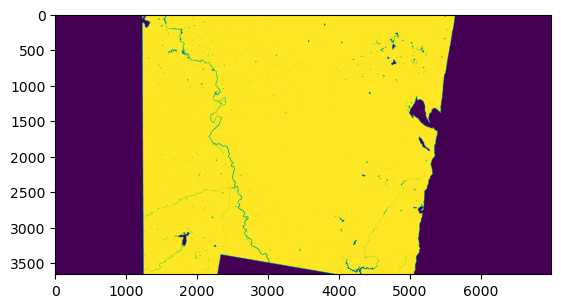

In [210]:
aoi_mask = X_aoi.astype(bool) & (~np.isnan(post_metric))

plt.imshow(aoi_mask)

<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_48368/495267237.py:50: SyntaxWarning: invalid escape sequence '\m'
  plt.annotate(f'$\max(F_1)=${f1_max:.2f}',


/u/aurora-r0/cabrera/opera_dist/testing/atbd_figs/park_fire_2024/park_fire_2024_precision_recall_curve.png


/tmp/ipykernel_48368/495267237.py:65: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(out_file, bbox_inches='tight', transparent=False, dpi=150)
/home/cabrera/python/miniconda3/envs/dist-s1/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


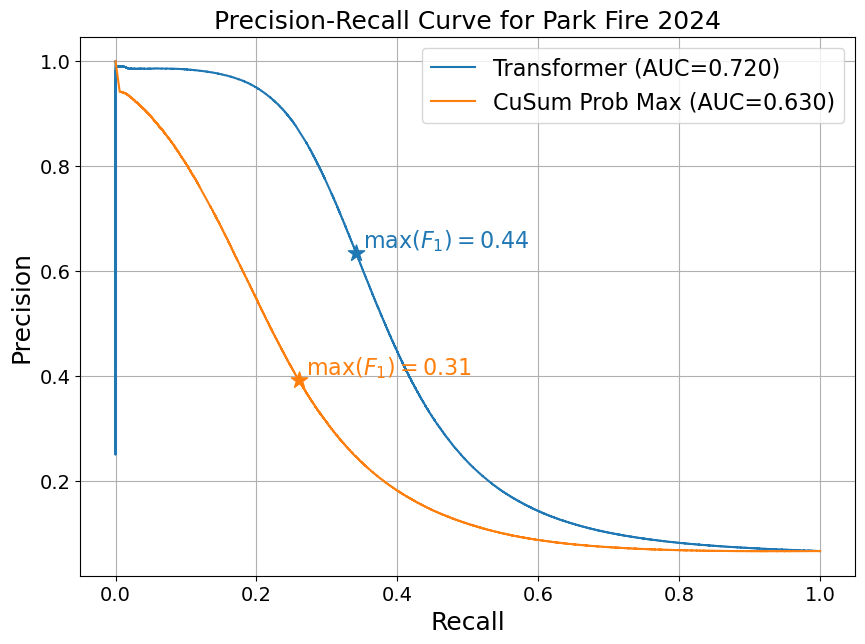

In [211]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, f1_score
# Plot precision-recall for each index in METRIC_IDX
metrics2plot = [6, 0]
plt.figure(figsize=(10, 7))
# for metric_idx in METRIC_IDX_LIST:
for metric_idx in metrics2plot:
    if metric_idx == 6:
        metric_text_name = 'Transformer'
    if metric_idx == 0:
        metric_text_name = 'CuSum Prob Max' 
    if metric_idx == 2:
        metric_text_name = 'Log Ratio VH'
        
    # Get pre and post metrics
    pre_metric = pre_metric_list_dict[metric_idx][selected_pre_idx]
    post_metric = post_metric_list_dict[metric_idx][selected_post_idx]

    # Select the values in the Area of Interest (AOI)
    metric_aoi = post_metric[aoi_mask]
    metric_aoi_pre = pre_metric[aoi_mask]
    metric_aoi_con = np.concatenate([metric_aoi, metric_aoi_pre], axis=0)

    # Create the change value labels for precision-recall calculation
    change_val = X_val[aoi_mask]
    change_val2 = np.zeros(change_val.shape)
    change_val_con = np.concatenate([change_val, change_val2], axis=0)

    # Compute precision-recall curve
    precisions, recalls, thresholds = precision_recall_curve(change_val_con, metric_aoi_con)

    # Calculate F1 scores
    f1_scores = 2 * recalls * precisions / (recalls + precisions + 1e-7)
    k_max = np.argmax(f1_scores)
    f1_max = f1_scores[k_max]

    # Calculate ROC curve
    fprs, tprs, _ = roc_curve(change_val_con, metric_aoi_con)
    auc = roc_auc_score(change_val_con, metric_aoi_con)

    # Plot precision-recall curve and capture the color
    line, = plt.plot(recalls, precisions, label=f'{metric_text_name} (AUC={auc:.3f})')

    # Get the color of the current curve
    curve_color = line.get_color()

    # Plot a star at the point of maximum F1 score with the same color
    plt.scatter(recalls[k_max], precisions[k_max], color=curve_color, marker='*', s=150, zorder=5)

    # Annotate the maximum F1 point with the same color
    plt.annotate(f'$\max(F_1)=${f1_max:.2f}', 
                 (recalls[k_max] + 0.01, precisions[k_max] + 0.01), 
                 fontsize=16, color=curve_color)

# Customize the plot
plt.xlabel('Recall', fontsize=18)
plt.ylabel('Precision', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.title(f'Precision-Recall Curve for {event_text_name}', fontsize=18)
plt.legend(fontsize=16)
plt.grid(True)
# Show the plot
if plot_export:
    out_file = OUT_DIR / f'{EVENT_NAME}_precision_recall_curve.png'
    print(out_file)
    plt.savefig(out_file, bbox_inches='tight', transparent=False, dpi=150)
plt.show()

Low thresh
0.8249705115352161
0.2789463093481379
0.4169199242451143
high thresh
0.9825090364872789
0.11584354071429309
0.20725096398082882
Low thresh
0.6411111643392656
0.1657202266090169
0.2633637596643685
high thresh
0.7450510044854575
0.1256400466426574
0.21502054507715554
/u/aurora-r0/cabrera/opera_dist/testing/atbd_figs/park_fire_2024/park_fire_2024_precision_recall_curve_thresholds_no_auc_nofscore.png


/tmp/ipykernel_48368/666661737.py:116: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(out_file, bbox_inches='tight', transparent=False, dpi=150)
/home/cabrera/python/miniconda3/envs/dist-s1/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


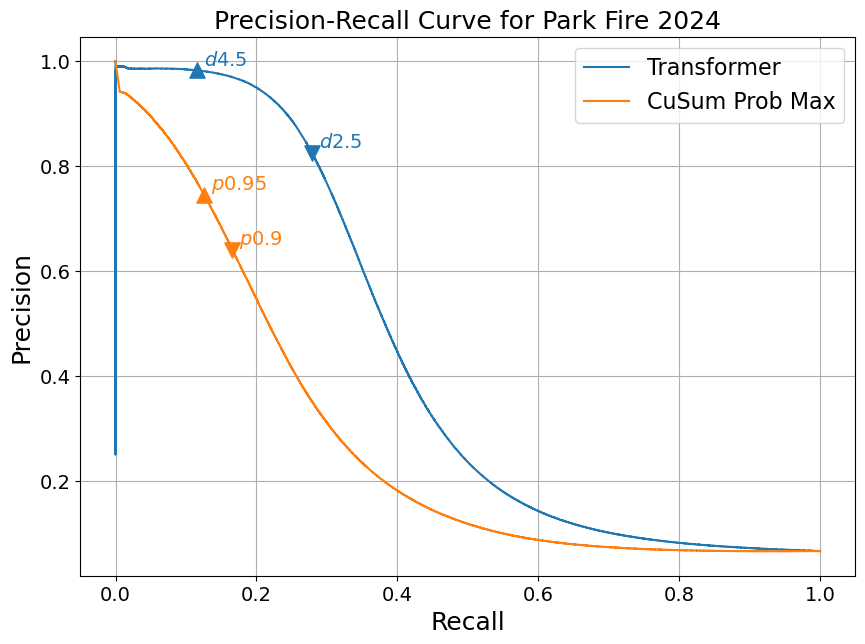

In [212]:
# from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, f1_score
# Plot precision-recall for each index in METRIC_IDX
metrics2plot = [6, 0]
plt.figure(figsize=(10, 7))
# for metric_idx in METRIC_IDX_LIST:
for metric_idx in metrics2plot:
    if metric_idx == 6:
        low_thresh = 2.5
        high_thresh = 4.5
        metric_text_name = 'Transformer'
        label_thresh =r'$d$'
    if metric_idx == 0:
        low_thresh = 0.9
        high_thresh = 0.95
        metric_text_name = 'CuSum Prob Max'
        label_thresh =r'$p$' 
    if metric_idx == 2:
        metric_text_name = 'Log Ratio VH'
        
    # Get pre and post metrics
    pre_metric = pre_metric_list_dict[metric_idx][selected_pre_idx]
    post_metric = post_metric_list_dict[metric_idx][selected_post_idx]

    # Select the values in the Area of Interest (AOI)
    metric_aoi = post_metric[aoi_mask]
    metric_aoi_pre = pre_metric[aoi_mask]
    metric_aoi_con = np.concatenate([metric_aoi, metric_aoi_pre], axis=0)

    # Create the change value labels for precision-recall calculation
    change_val = X_val[aoi_mask]
    change_val2 = np.zeros(change_val.shape)
    change_val_con = np.concatenate([change_val, change_val2], axis=0)

    # Compute precision-recall curve
    precisions, recalls, thresholds = precision_recall_curve(change_val_con, metric_aoi_con)

    # Calculate F1 scores
    f1_scores = 2 * recalls * precisions / (recalls + precisions + 1e-7)
    k_max = np.argmax(f1_scores)
    f1_max = f1_scores[k_max]

    # Find the index of the threshold closest to 2.5
    index_low = np.searchsorted(thresholds, low_thresh)
    index_high = np.searchsorted(thresholds, high_thresh) 

    # Make sure the index is within bounds
    if index_low >= len(thresholds):
        print("---> Threshold value exceeds the range of computed thresholds.")
    else:
        # Retrieve the F1 score, precision, and recall at this index
        precision_low_thresh = precisions[index_low]
        recall_low_thresh = recalls[index_low]
        f1_low_thresh = f1_scores[index_low]

    # Make sure the index is within bounds
    if index_high >= len(thresholds):
        print("---> Threshold value exceeds the range of computed thresholds.")
    else:
        # Retrieve the F1 score, precision, and recall at this index
        precision_high_thresh = precisions[index_high]
        recall_high_thresh = recalls[index_high]
        f1_high_thresh = f1_scores[index_high]

    print("Low thresh")
    print(precision_low_thresh)
    print(recall_low_thresh)
    print(f1_low_thresh)
    print("high thresh")
    print(precision_high_thresh)
    print(recall_high_thresh)
    print(f1_high_thresh)

    # Plot precision-recall curve and capture the color
    line, = plt.plot(recalls, precisions, label=f'{metric_text_name}')

    # Get the color of the current curve
    curve_color = line.get_color()

    # # Plot a star at the point of maximum F1 score with the same color
    # plt.scatter(recalls[k_max], precisions[k_max], color=curve_color, marker='*', s=150, zorder=5)
    # # Annotate the maximum F1 point with the same color
    # plt.annotate(f'$\max(F_1)=${f1_max:.2f}', 
    #              (recalls[k_max] + 0.01, precisions[k_max] + 0.01), 
    #              fontsize=16, color=curve_color)

    # Plot a star at the point of maximum F1 score with the same color
    plt.scatter(recall_low_thresh, precision_low_thresh, color=curve_color, marker='v', s=120, zorder=1, alpha=1)
    # plt.axvline(x=recall_low_thresh, color=curve_color, linestyle=(0, (3, 5, 1, 5)), label=f'Threshold {low_thresh}')
    # Annotate the maximum F1 point with the same color
    plt.annotate(f'{label_thresh}{low_thresh}', 
                #  (recall_low_thresh - 0.06, precision_low_thresh - 0.06),
                 (recall_low_thresh + 0.01, precision_low_thresh + 0.01), 
                 fontsize=14, color=curve_color)

    # Plot a star at the point of maximum F1 score with the same color
    plt.scatter(recall_high_thresh, precision_high_thresh, color=curve_color, marker='^', s=120, zorder=1, alpha=1)
    # plt.axvline(x=recall_high_thresh, color=curve_color, linestyle=(0, (3, 5, 1, 5, 1, 5)), label=f'Threshold {high_thresh}')
    # Annotate the maximum F1 point with the same color
    plt.annotate(f'{label_thresh}{high_thresh}', 
                #  (recall_high_thresh - 0.06, precision_high_thresh - 0.06), 
                 (recall_high_thresh + 0.01, precision_high_thresh + 0.01),
                 fontsize=14, color=curve_color)


# Customize the plot
plt.xlabel('Recall', fontsize=18)
plt.ylabel('Precision', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.title(f'Precision-Recall Curve for {event_text_name}', fontsize=18)
plt.legend(fontsize=16)
plt.grid(True)
# Show the plot
if plot_export:
    out_file = OUT_DIR / f'{EVENT_NAME}_precision_recall_curve_thresholds_no_auc_nofscore.png'
    print(out_file)
    plt.savefig(out_file, bbox_inches='tight', transparent=False, dpi=150)
plt.show()

### Plot pre and post images for each metric 

Plotting --> Transformer Post Park Fire 2024
/u/aurora-r0/cabrera/opera_dist/testing/atbd_figs/park_fire_2024/transformer/post_2024-08-10_transformer_track137_park-fire-2024_metric_disturbance_thresh.png


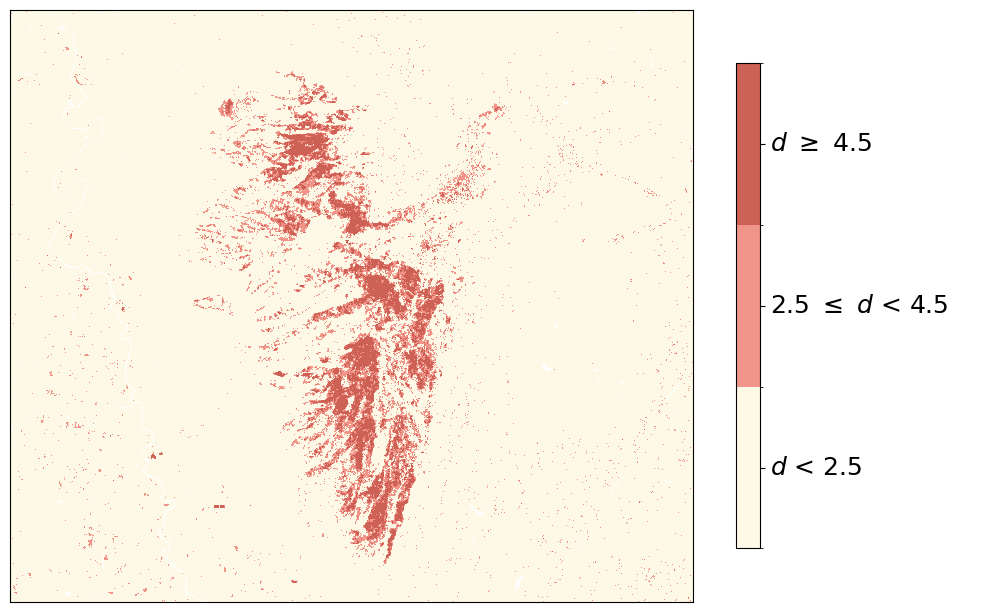

Plotting --> Transformer Pre Park Fire 2024
/u/aurora-r0/cabrera/opera_dist/testing/atbd_figs/park_fire_2024/transformer/pre_2024-07-05_transformer_track137_park-fire-2024_metric_disturbance_thresh.png


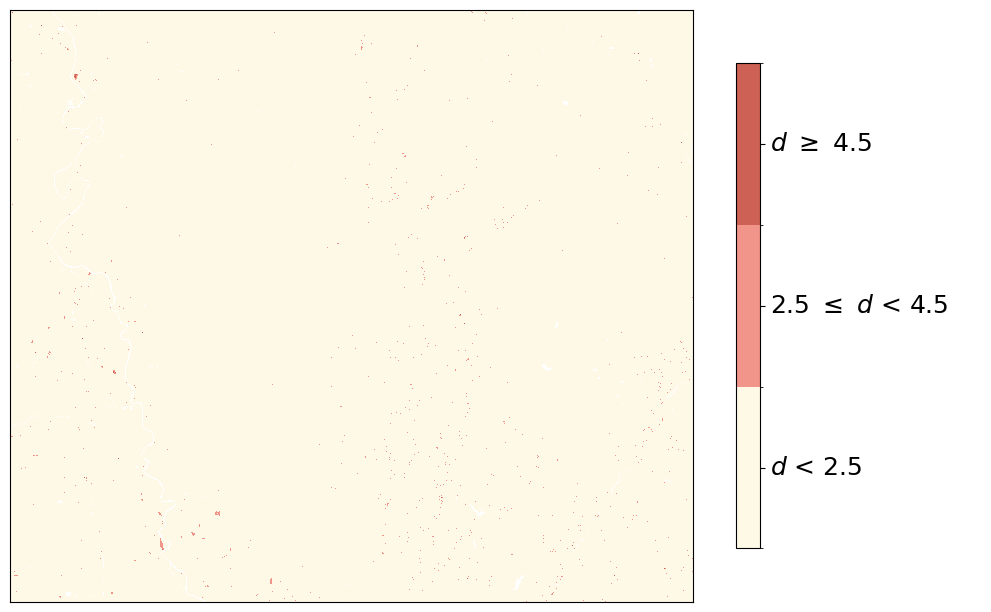

Plotting --> CuSum Prob Max Post Park Fire 2024
/u/aurora-r0/cabrera/opera_dist/testing/atbd_figs/park_fire_2024/cusum_prob_max/post_2024-08-10_cusum_prob_max_track137_park-fire-2024_metric_disturbance_thresh.png


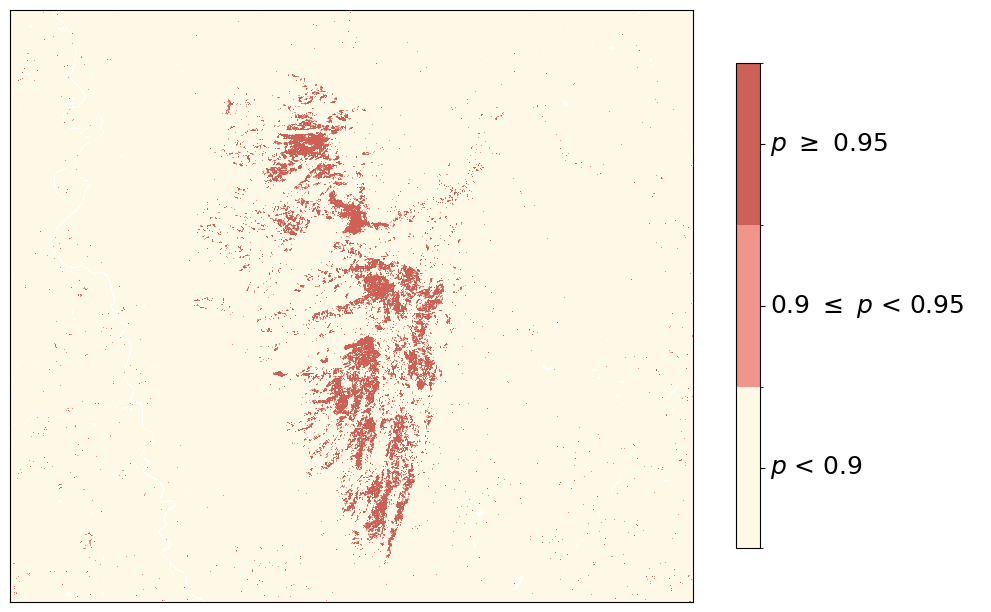

Plotting --> CuSum Prob Max Pre Park Fire 2024
/u/aurora-r0/cabrera/opera_dist/testing/atbd_figs/park_fire_2024/cusum_prob_max/pre_2024-07-05_cusum_prob_max_track137_park-fire-2024_metric_disturbance_thresh.png


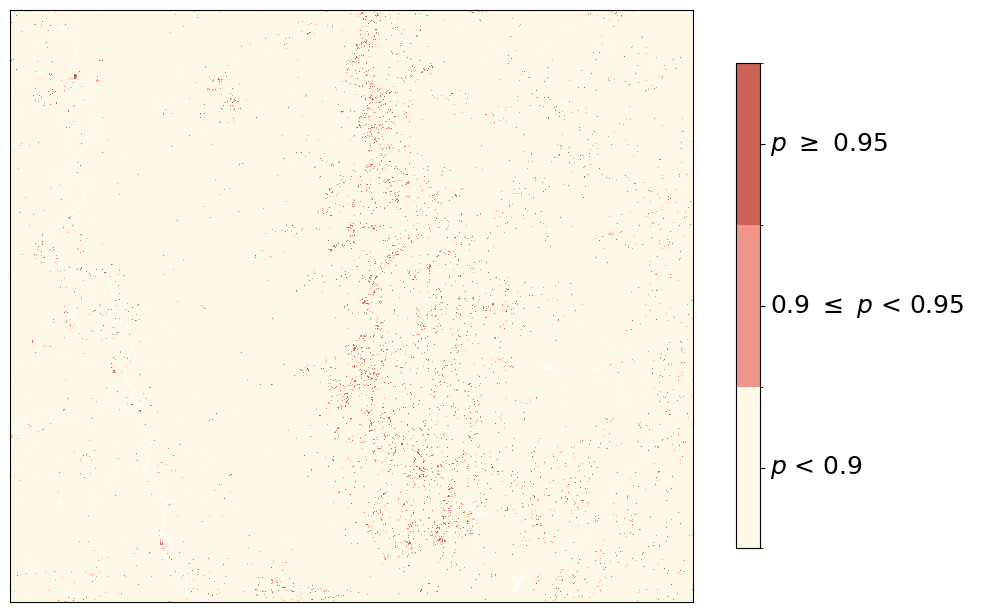

In [213]:
for metric_idx in metrics2plot:
    metric2plot_lst = [post_metric_list_dict[metric_idx][selected_post_idx], pre_metric_list_dict[metric_idx][selected_pre_idx]]
    metric_names_lst = [post_metric_names_dict[metric_idx][selected_post_idx], pre_metric_names_dict[metric_idx][selected_pre_idx]]
    pre_post_lst = ['Post', 'Pre']
    for idx, metric2plot in enumerate(metric2plot_lst):
        pre_post = pre_post_lst[idx]

        if metric_idx == 6:
            metric_text_name = 'Transformer'
            # Original disturbance plot
            bounds = [0, 2.5, 4.5, np.nanmax(metric2plot)]  # Define boundaries for the color ranges
            ticks = [1.25, 3.5, (np.nanmax(metric2plot) + 4.5) / 2]  # Midpoints for each range 
            tick_labels = [r'$d$ < 2.5', r'2.5 $\leq$ $d$ < 4.5', r'$d$ $\geq$ 4.5'] # Labels for each range
            # bounds = [0, 2.5, np.nanmax(metric2plot)]  # Define boundaries for the color ranges
            # ticks = [1.25, 8]  # Midpoints for each range 
            # tick_labels = [r'No disturbance', r'Disturbance'] # Labels for each range
        if metric_idx == 0:
            metric_text_name = 'CuSum Prob Max' 
            # Original disturbance plot
            bounds = [0, 0.9, 0.95, np.nanmax(metric2plot)]  # Define boundaries for the color ranges
            ticks = [0.45, 0.925, (np.nanmax(metric2plot) + 0.95) / 2]  # Midpoints for each range 
            tick_labels = [r'$p$ < 0.9', r'0.9 $\leq$ $p$ < 0.95', r'$p$ $\geq$ 0.95'] # Labels for each range
            # bounds = [0, 0.9, np.nanmax(metric2plot)]  # Define boundaries for the color ranges
            # ticks = [1.25, 8]  # Midpoints for each range 
            # tick_labels = [r'No disturbance', r'Disturbance'] # Labels for each range
        if metric_idx == 2:
            metric_text_name = 'Log Ratio VH'

        # Define the color patterns as RGBA values (with values scaled between 0 and 1 for matplotlib)
        colors = [(254/255, 249/255, 231/255, 1),    # (18, 18, 18, 255) for values < 2.5
                  (241/255, 148/255, 138/255, 1),    # (224, 27, 7, 255) for 2.5 <= values < 4.5
                  (205/255, 97/255, 85/255, 1)]  # (222, 224, 67, 255) for values >= 4.5

        # Create a colormap from these colors
        cmap = ListedColormap(colors)
        # Create a normalizer to map values to the correct color ranges
        norm = BoundaryNorm(bounds, cmap.N)

        fig, ax = plt.subplots(figsize=(10, 10))
        # Show the band data (rtc_metric) with the custom colormap and normalization
        im_data = ax.imshow(metric2plot[s], cmap=cmap, norm=norm, interpolation='none')

        # Set up bounds for the colorbar
        bounds_fig = bounds # Color region boundaries

        # Create the colorbar
        cbar = fig.colorbar(im_data, 
                            ax=ax, 
                            shrink=0.5, 
                            pad=0.05, 
                            boundaries=bounds_fig, 
                            cmap=cmap, 
                            ticks=ticks)

        # Set the tick labels at the midpoints of the colors
        cbar.set_ticklabels(tick_labels, fontsize=18, fontfamily='sans-serif')

        # Ensure the tick labels use a sans-serif font
        for tick in cbar.ax.get_yticklabels():
            tick.set_fontfamily('sans-serif')
            tick.set_verticalalignment('center')  # Center vertically

        ax.set_xticks([])
        ax.set_yticks([])

        # Add movable, white-colored text to the plot
        # this text is used only to keep the same aspect ration between figures (it does not show as long as the background is white)
        text = ax.text(1.28, 0.5, r'0.9 $\leq$ $p$ < 0.95', color='white', fontsize=18,
                       transform=ax.transAxes, ha='center', va='center') 
        
        plt.tight_layout()
        # plt.title(f'{metric_text_name} {pre_post} {event_text_name}', fontsize=14) # remove once things are set
        print(f'Plotting --> {metric_text_name} {pre_post} {event_text_name}')
        # Show the plot
        if plot_export:
            out_file = OUT_DIR / all_metric_names_lst[metric_idx] / f'{metric_names_lst[idx]}_metric_disturbance_thresh.png'
            print(out_file)
            plt.savefig(out_file, bbox_inches='tight', transparent=False, dpi=150)
        plt.show()
